<a href="https://colab.research.google.com/github/VishalK720/vishalcset343/blob/main/lab_1_1037.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# AI in Healthcare — Lab Assignment 1

**Course:** B.Tech  
**Course Code:** CSET343  
**Course Name:** AI in Healthcare  
**Year:** 4th Year  
**Semester:** VII  

## Objective

Implementation of a program to read tabular, textual, image, signal, and medical data in different formats.

## Modalities Covered

1. Tabular Data — Cleveland Heart Disease Dataset
2. Signal Data — MIT-BIH Arrhythmia Database
3. Textual Data — Clinical Note
4. Image Data — Medical Image
5. Medical Data — Multimodal Integration

In [2]:
# Install required packages

!pip install -q pandas numpy matplotlib seaborn scikit-learn wfdb ucimlrepo

print("Required packages installed successfully.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 163.9/163.9 kB 1.4 MB/s eta 0:00:00
Required packages installed successfully.


In [3]:
# Import required libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import wfdb

from PIL import Image
from io import BytesIO

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from ucimlrepo import fetch_ucirepo

import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")

pd.set_option("display.max_columns", None)

print("Libraries imported successfully.")

Libraries imported successfully.


# 1. Tabular Data — Cleveland Heart Disease Dataset

The Cleveland Heart Disease Dataset is used as the primary tabular medical dataset.

The dataset contains patient-level clinical attributes such as age, sex, chest pain type, resting blood pressure, cholesterol, maximum heart rate, exercise-induced angina and other cardiovascular measurements.

The target variable represents the presence of heart disease.


In [4]:
# Fetch the Cleveland Heart Disease Dataset from UCI

heart_disease = fetch_ucirepo(id=45)

X = heart_disease.data.features
y = heart_disease.data.targets

print("Dataset acquired successfully.")
print("Features shape:", X.shape)
print("Target shape:", y.shape)

Dataset acquired successfully.
Features shape: (303, 13)
Target shape: (303, 1)


In [5]:
# Display first 5 rows of features

X.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0


In [6]:
# Display target values

y.head()

,num
0,0
1,2
2,1
3,0
4,0


In [7]:
# Inspect dataset structure

print("Number of rows:", X.shape[0])
print("Number of columns:", X.shape[1])

print("\nFeature names:")
print(X.columns.tolist())

print("\nData types:")
print(X.dtypes)

Number of rows: 303
Number of columns: 13

Feature names:
['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']

Data types:
age           int64
sex           int64
cp            int64
trestbps      int64
chol          int64
fbs           int64
restecg       int64
thalach       int64
exang         int64
oldpeak     float64
slope         int64
ca          float64
thal        float64
dtype: object


In [8]:
# Check missing values

missing_values = X.isnull().sum()

print("Missing values in each feature:")
print(missing_values)

print("\nTotal missing values:", missing_values.sum())

Missing values in each feature:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          4
thal        2
dtype: int64

Total missing values: 6


In [9]:
# Combine features and target into one DataFrame

df_heart = X.copy()

# Add target column
df_heart["target"] = y.iloc[:, 0].values

print("Combined dataset:")
display(df_heart.head())

Combined dataset:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,2
2,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
3,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


In [10]:
# Convert the original target into a binary target
# 0 = no heart disease
# 1+ = presence of heart disease

df_heart["target_binary"] = (
    df_heart["target"] > 0
).astype(int)

print("Binary target distribution:")
print(df_heart["target_binary"].value_counts())

Binary target distribution:
target_binary
0    164
1    139
Name: count, dtype: int64


In [11]:
# Basic descriptive statistics

df_heart.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target,target_binary
count,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,303.000000,299.000000,301.000000,303.000000,303.000000
mean,54.438944,0.679868,3.158416,131.689769,246.693069,0.148515,0.990099,149.607261,0.326733,1.039604,1.600660,0.672241,4.734219,0.937294,0.458746
std,9.038662,0.467299,0.960126,17.599748,51.776918,0.356198,0.994971,22.875003,0.469794,1.161075,0.616226,0.937438,1.939706,1.228536,0.499120
min,29.000000,0.000000,1.000000,94.000000,126.000000,0.000000,0.000000,71.000000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000,0.000000
25%,48.000000,0.000000,3.000000,120.000000,211.000000,0.000000,0.000000,133.500000,0.000000,0.000000,1.000000,0.000000,3.000000,0.000000,0.000000
50%,56.000000,1.000000,3.000000,130.000000,241.000000,0.000000,1.000000,153.000000,0.000000,0.800000,2.000000,0.000000,3.000000,0.000000,0.000000
75%,61.000000,1.000000,4.000000,140.000000,275.000000,0.000000,2.000000,166.000000,1.000000,1.600000,2.000000,1.000000,7.000000,2.000000,1.000000
max,77.000000,1.000000,4.000000,200.000000,564.000000,1.000000,2.000000,202.000000,1.000000,6.200000,3.000000,3.000000,7.000000,4.000000,1.000000


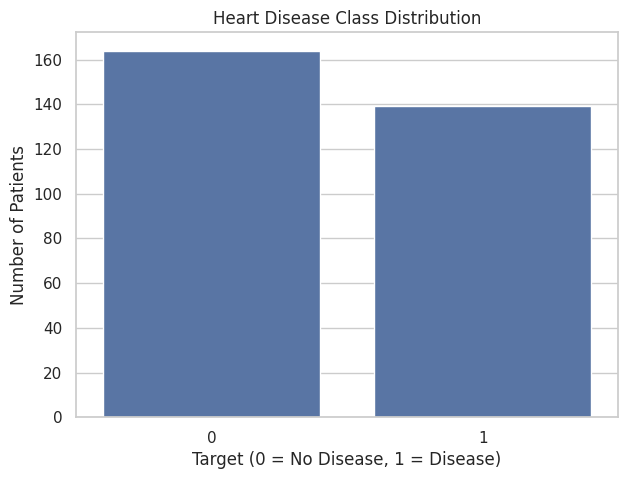

In [12]:
# Visualize heart disease class distribution

plt.figure(figsize=(7, 5))

sns.countplot(
    data=df_heart,
    x="target_binary"
)

plt.title("Heart Disease Class Distribution")
plt.xlabel("Target (0 = No Disease, 1 = Disease)")
plt.ylabel("Number of Patients")

plt.show()

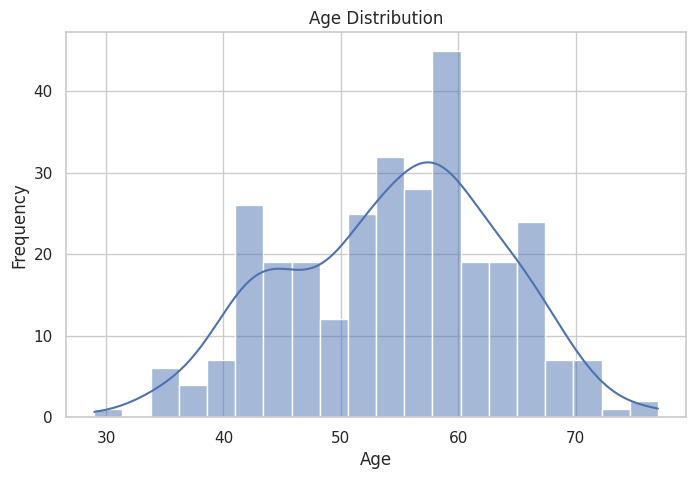

In [13]:
# Plot age distribution

plt.figure(figsize=(8, 5))

sns.histplot(
    df_heart["age"],
    bins=20,
    kde=True
)

plt.title("Age Distribution")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.show()

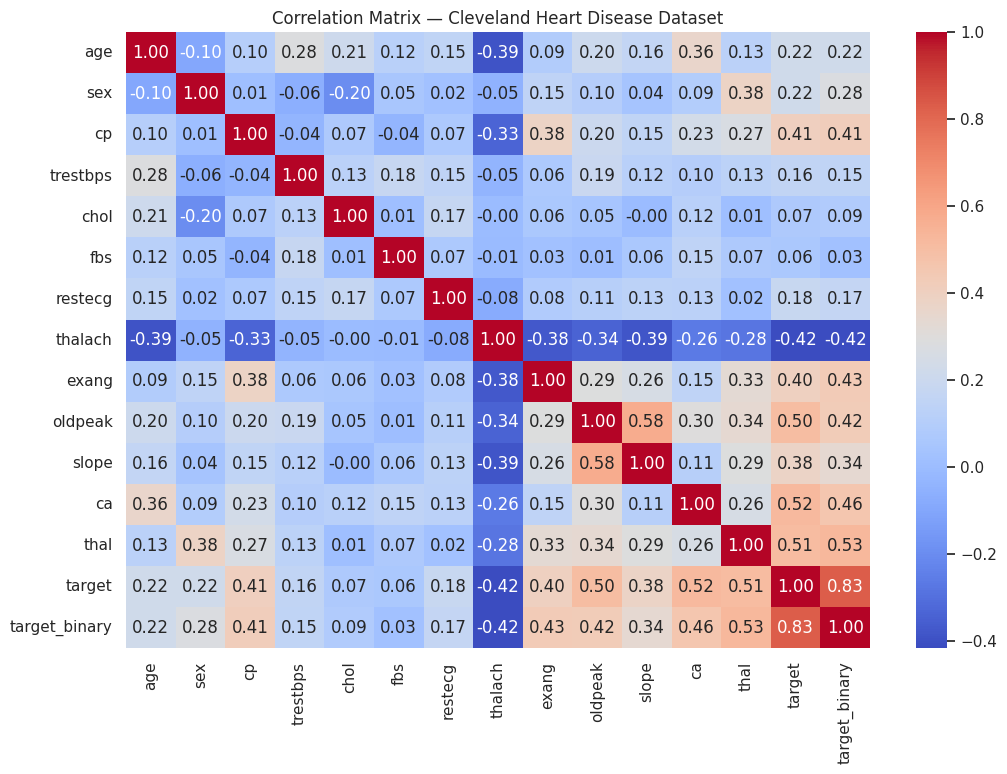

In [14]:
# Correlation heatmap

plt.figure(figsize=(12, 8))

correlation = df_heart.corr(numeric_only=True)

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Matrix — Cleveland Heart Disease Dataset")

plt.show()

# 2. Signal Data — MIT-BIH Arrhythmia Database

The MIT-BIH Arrhythmia Database contains ECG recordings and expert annotations.

The WFDB format uses files such as `.dat`, `.hea`, and `.atr`.

The `wfdb` Python library is used to load the ECG signal and its annotations.

In [15]:
# Load MIT-BIH Arrhythmia Database record 100

record = wfdb.rdrecord(
    "100",
    pn_dir="mitdb"
)

annotation = wfdb.rdann(
    "100",
    "atr",
    pn_dir="mitdb"
)

print("ECG record loaded successfully.")

print("Number of samples:", record.sig_len)
print("Sampling frequency:", record.fs)
print("Number of channels:", record.n_sig)

ECG record loaded successfully.
Number of samples: 650000
Sampling frequency: 360
Number of channels: 2


In [16]:
# Display ECG signal information

print("Signal names:", record.sig_name)
print("Units:", record.units)
print("Sampling frequency:", record.fs, "Hz")
print("Signal shape:", record.p_signal.shape)

Signal names: ['MLII', 'V5']
Units: ['mV', 'mV']
Sampling frequency: 360 Hz
Signal shape: (650000, 2)


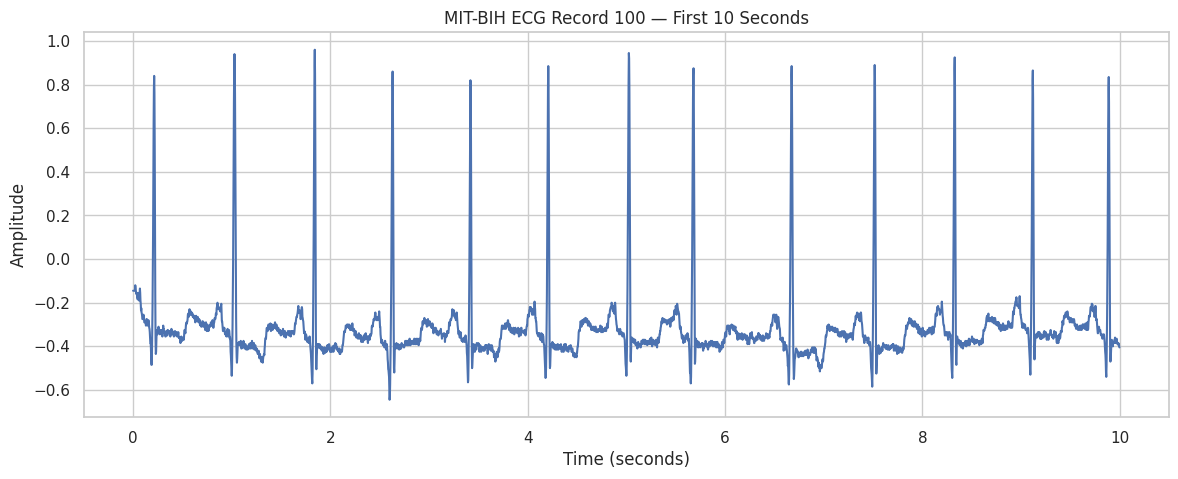

In [17]:
# Plot the first 10 seconds of ECG signal

seconds = 10
samples = int(seconds * record.fs)

signal = record.p_signal[:samples, 0]

time = np.arange(samples) / record.fs

plt.figure(figsize=(14, 5))

plt.plot(time, signal)

plt.title("MIT-BIH ECG Record 100 — First 10 Seconds")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")

plt.show()

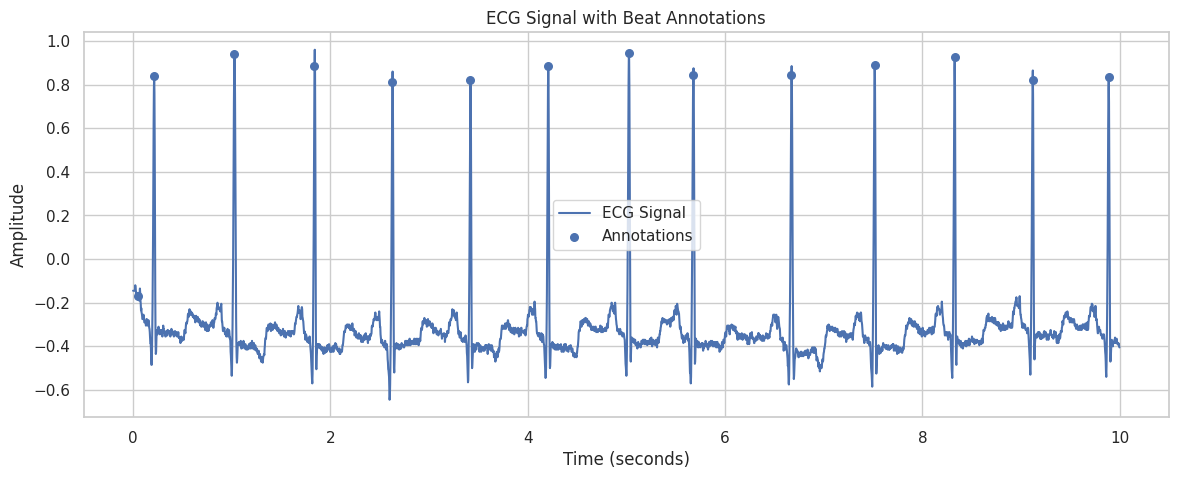

In [18]:
# Plot ECG with beat annotations

plt.figure(figsize=(14, 5))

plt.plot(
    time,
    signal,
    label="ECG Signal"
)

# Select annotations occurring within the plotted segment
annotation_mask = annotation.sample < samples

annotation_samples = annotation.sample[annotation_mask]
annotation_symbols = np.array(
    annotation.symbol
)[annotation_mask]

annotation_times = annotation_samples / record.fs

annotation_signal_values = record.p_signal[
    annotation_samples,
    0
]

plt.scatter(
    annotation_times,
    annotation_signal_values,
    marker="o",
    s=30,
    label="Annotations"
)

plt.title("ECG Signal with Beat Annotations")
plt.xlabel("Time (seconds)")
plt.ylabel("Amplitude")
plt.legend()

plt.show()

In [19]:
# Calculate intervals between ECG annotations

annotation_samples = annotation.sample

# Convert sample positions to seconds
annotation_times_all = annotation_samples / record.fs

# Calculate time differences
beat_intervals = np.diff(annotation_times_all)

print("Mean beat interval:",
      np.mean(beat_intervals))

print("Median beat interval:",
      np.median(beat_intervals))

print("Standard deviation:",
      np.std(beat_intervals))

Mean beat interval: 0.7943161265092633
Median beat interval: 0.7972222222222172
Standard deviation: 0.050584340991449706


# 3. Textual Data — Clinical Note

Healthcare systems also contain free-text information such as clinical notes.

For demonstration, a small synthetic clinical note is created so that no real patient's personal information is exposed.

The text will be read, cleaned, tokenized and analyzed using simple NLP techniques.

In [20]:
# Create a synthetic clinical note

clinical_note = """
Patient presents with chest pain and shortness of breath.
The patient reports fatigue during physical activity.
Blood pressure is elevated and heart rate is irregular.
Further cardiovascular evaluation and ECG assessment are recommended.
"""

print(clinical_note)


Patient presents with chest pain and shortness of breath.
The patient reports fatigue during physical activity.
Blood pressure is elevated and heart rate is irregular.
Further cardiovascular evaluation and ECG assessment are recommended.



In [21]:
# Save the synthetic clinical note as a text file

with open("clinical_note.txt", "w") as file:
    file.write(clinical_note)

print("Clinical note saved as clinical_note.txt")

Clinical note saved as clinical_note.txt


In [22]:
# Read the clinical note from the text file

with open("clinical_note.txt", "r") as file:
    loaded_note = file.read()

print("Loaded clinical note:")
print(loaded_note)

Loaded clinical note:

Patient presents with chest pain and shortness of breath.
The patient reports fatigue during physical activity.
Blood pressure is elevated and heart rate is irregular.
Further cardiovascular evaluation and ECG assessment are recommended.



In [23]:
# Basic text cleaning

clean_note = loaded_note.lower()

# Remove basic punctuation
import re

clean_note = re.sub(
    r"[^a-zA-Z0-9\s]",
    "",
    clean_note
)

print(clean_note)


patient presents with chest pain and shortness of breath
the patient reports fatigue during physical activity
blood pressure is elevated and heart rate is irregular
further cardiovascular evaluation and ecg assessment are recommended



In [24]:
# Tokenize the clinical note

tokens = clean_note.split()

print("Tokens:")
print(tokens)

print("\nNumber of tokens:", len(tokens))

Tokens:
['patient', 'presents', 'with', 'chest', 'pain', 'and', 'shortness', 'of', 'breath', 'the', 'patient', 'reports', 'fatigue', 'during', 'physical', 'activity', 'blood', 'pressure', 'is', 'elevated', 'and', 'heart', 'rate', 'is', 'irregular', 'further', 'cardiovascular', 'evaluation', 'and', 'ecg', 'assessment', 'are', 'recommended']

Number of tokens: 33


In [25]:
from collections import Counter

# Calculate word frequencies

word_frequency = Counter(tokens)

print("Word frequency:")
print(word_frequency.most_common())

Word frequency:
[('and', 3), ('patient', 2), ('is', 2), ('presents', 1), ('with', 1), ('chest', 1), ('pain', 1), ('shortness', 1), ('of', 1), ('breath', 1), ('the', 1), ('reports', 1), ('fatigue', 1), ('during', 1), ('physical', 1), ('activity', 1), ('blood', 1), ('pressure', 1), ('elevated', 1), ('heart', 1), ('rate', 1), ('irregular', 1), ('further', 1), ('cardiovascular', 1), ('evaluation', 1), ('ecg', 1), ('assessment', 1), ('are', 1), ('recommended', 1)]


# 4. Image Data — Medical Image Demonstration

Medical imaging data can be stored in formats such as PNG, JPEG, DICOM and NIfTI.

For this demonstration, a synthetic medical-style image is generated and processed using Pillow.

The image is loaded, displayed and resized.

In [26]:
# Create a synthetic grayscale medical-style image

image_array = np.random.randint(
    0,
    256,
    size=(256, 256),
    dtype=np.uint8
)

medical_image = Image.fromarray(
    image_array,
    mode="L"
)

medical_image.save(
    "synthetic_medical_image.png"
)

print("Synthetic medical image created.")

Synthetic medical image created.


In [27]:
# Read the image using Pillow

image = Image.open(
    "synthetic_medical_image.png"
)

print("Image format:", image.format)
print("Image mode:", image.mode)
print("Image size:", image.size)

Image format: PNG
Image mode: L
Image size: (256, 256)


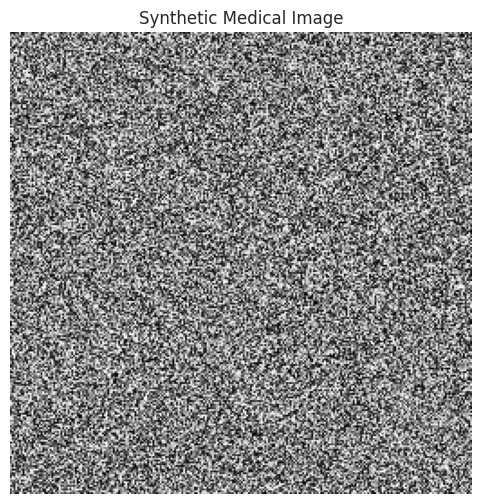

In [28]:
# Display the image

plt.figure(figsize=(6, 6))

plt.imshow(
    image,
    cmap="gray"
)

plt.title("Synthetic Medical Image")

plt.axis("off")

plt.show()

In [29]:
# Resize the image

resized_image = image.resize(
    (128, 128)
)

print("Original size:", image.size)
print("Resized size:", resized_image.size)

Original size: (256, 256)
Resized size: (128, 128)


# 5. Medical Data — Multimodal Integration

Medical AI systems often combine multiple modalities:

- Tabular clinical information
- ECG signals
- Clinical text
- Medical images

Each modality contains different information about the patient.

A multimodal system can combine these sources using a common patient identifier and, where necessary, timestamps.

In [30]:
# Demonstration of a unified multimodal patient representation

patient_record = {
    "patient_id": "P001",
    "tabular_data": "Heart disease clinical features",
    "ecg_data": "MIT-BIH ECG signal",
    "clinical_note": "Synthetic clinical note",
    "medical_image": "Synthetic medical image"
}

for key, value in patient_record.items():
    print(f"{key}: {value}")

patient_id: P001
tabular_data: Heart disease clinical features
ecg_data: MIT-BIH ECG signal
clinical_note: Synthetic clinical note
medical_image: Synthetic medical image


# 6. Baseline Classifier — Logistic Regression

A simple Logistic Regression model is trained on the Cleveland Heart Disease tabular data to demonstrate a basic downstream machine-learning task.

The target is binary:

- 0 — No heart disease
- 1 — Heart disease

In [31]:
# Prepare features and binary target

X_model = df_heart.drop(
    columns=["target", "target_binary"]
)

y_model = df_heart["target_binary"]

# Handle missing values using median imputation
X_model = X_model.fillna(
    X_model.median(numeric_only=True)
)

print("Model input shape:", X_model.shape)
print("Target shape:", y_model.shape)

Model input shape: (303, 13)
Target shape: (303,)


In [32]:
# Split the dataset into training and testing sets

X_train, X_test, y_train, y_test = train_test_split(
    X_model,
    y_model,
    test_size=0.20,
    random_state=42,
    stratify=y_model
)

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 242
Testing samples: 61


In [33]:
# Standardize numerical features

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

print("Feature standardization completed.")

Feature standardization completed.


In [34]:
# Train Logistic Regression model

model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

model.fit(
    X_train_scaled,
    y_train
)

print("Logistic Regression model trained successfully.")

Logistic Regression model trained successfully.


In [35]:
# Generate predictions

y_pred = model.predict(
    X_test_scaled
)

y_probability = model.predict_proba(
    X_test_scaled
)[:, 1]

print("Predictions generated successfully.")

Predictions generated successfully.


In [36]:
# Calculate accuracy

accuracy = accuracy_score(
    y_test,
    y_pred
)

print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.8689


In [37]:
# Calculate ROC AUC

roc_auc = roc_auc_score(
    y_test,
    y_probability
)

print(f"ROC AUC: {roc_auc:.4f}")

ROC AUC: 0.9513


Confusion Matrix:
[[27  6]
 [ 2 26]]


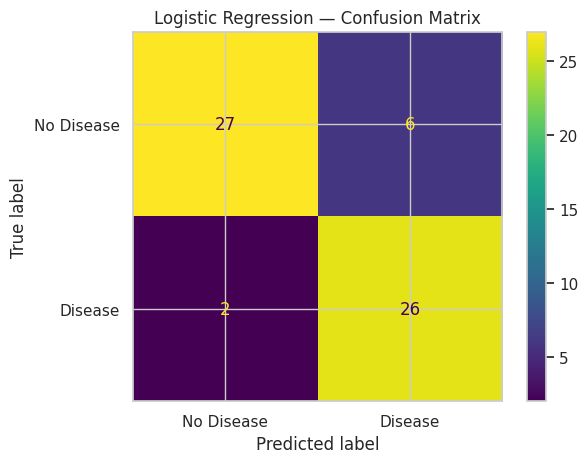

In [38]:
# Generate confusion matrix

cm = confusion_matrix(
    y_test,
    y_pred
)

print("Confusion Matrix:")
print(cm)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["No Disease", "Disease"]
)

disp.plot()

plt.title("Logistic Regression — Confusion Matrix")

plt.show()

# 7. Multimodal Healthcare AI — Integration Discussion

A healthcare AI system can combine information from different modalities.

### Tabular Data

Clinical variables such as age, blood pressure, cholesterol and maximum heart rate provide structured patient information.

### ECG Signal

ECG recordings provide temporal physiological information. Features such as beat intervals and rhythm-related measurements can be extracted.

### Clinical Text

Clinical notes contain symptoms, observations and recommendations that may not be represented in structured numerical data.

### Medical Images

Medical images provide visual information that can be analyzed using image-processing and deep-learning techniques.

### Multimodal Fusion

Features extracted from these modalities can be linked using a common patient identifier and, where appropriate, timestamps.

For example:

Patient
→ Tabular Clinical Features
→ ECG Features
→ Text Features
→ Image Features
→ Combined Feature Representation
→ Machine Learning Model
→ Prediction

# 8. Conclusion

In this experiment, different healthcare data modalities were successfully demonstrated.

1. Tabular data was acquired and loaded using Pandas/UCI tools.
2. Dataset structure, data types and missing values were inspected.
3. Basic exploratory analysis was performed on the Cleveland Heart Disease dataset.
4. The original heart disease target was converted into a binary classification target.
5. MIT-BIH ECG data was loaded using WFDB.
6. ECG signals and their expert annotations were visualized.
7. Basic beat interval statistics were calculated.
8. A synthetic clinical note was created, saved as a text file and read using Python.
9. Basic text cleaning, tokenization and word-frequency analysis were demonstrated.
10. A synthetic medical image was created and processed using Pillow.
11. The image was displayed and resized.
12. A simple multimodal healthcare data-integration structure was demonstrated.
13. A Logistic Regression baseline model was trained for heart disease classification.
14. Model performance was evaluated using accuracy, ROC AUC and a confusion matrix.

This experiment demonstrates the different data-ingestion requirements of multimodal healthcare AI systems.